<a href="https://colab.research.google.com/github/shindesai125/Deep-Learning/blob/main/ANN%20with%20Hyperparameter%20Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence

In [78]:
max_features = 10000    # Load top 10,000 most frequent words

maxlen = 200   # cut reviews after 200 words


(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

In [79]:
# Pad sequences so they all have the same length
X_train = sequence.pad_sequences(X_train, maxlen=maxlen)
X_test = sequence.pad_sequences(X_test, maxlen=maxlen)

In [80]:
print("The shape of X_train is:", X_train.shape)
print("The shape of X_test is:", X_test.shape)

The shape of X_train is: (25000, 200)
The shape of X_test is: (25000, 200)


In [81]:
from tensorflow import keras
from tensorflow.keras import layers
!pip install keras_tuner
import keras_tuner as kt

In [97]:
def model_builder(hp):
    model = keras.Sequential()

    # Embedding layer
    model.add(layers.Embedding(
        input_dim=max_features,
        output_dim=hp.Int("embed_dim", 32, 128, step=32),
        input_length=maxlen
    ))

    # 🔑 Collapse sequence -> single vector
    model.add(layers.GlobalAveragePooling1D())

    # Hidden layers
    for i in range(hp.Int("num_layers", 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f"units_{i}", min_value=32, max_value=256, step=32),
            activation=hp.Choice("activation", ["relu", "tanh"])
        ))

    # Output layer
    model.add(layers.Dense(1, activation="sigmoid"))

    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [98]:
tuner = kt.RandomSearch(model_builder, objective="val_accuracy", max_trials=5, executions_per_trial=2, directory = "my_dir", project_name= "imdb_tuning")

Reloading Tuner from my_dir/imdb_tuning/tuner0.json


In [99]:
tuner.search(X_train, y_train,
             epochs=5,
             validation_split=0.2)

In [101]:
best_hps=tuner.get_best_hyperparameters(num_trials = 1)[0]

print("Best embedding dim:", best_hps.get("embed_dim"))
print("Best number of layers:", best_hps.get("num_layers"))
print("Best activation:", best_hps.get("activation"))
print("Best learning rate:", best_hps.get("learning_rate"))


best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()


Best embedding dim: 64
Best number of layers: 5
Best activation: tanh
Best learning rate: 0.001


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, 200, 64)          │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (32, 64)               │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 32)               │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 32)               │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 32)               │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 32)               │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 32)               │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (32, 1)                │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,337 (2.47 MB)

 Trainable params: 646,337 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [110]:
history=best_model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=None)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9660 - loss: 0.1086 - val_accuracy: 0.8518 - val_loss: 0.4241
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9745 - loss: 0.0909 - val_accuracy: 0.8456 - val_loss: 0.5290
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9724 - loss: 0.0911 - val_accuracy: 0.8485 - val_loss: 0.4717
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9746 - loss: 0.0846 - val_accuracy: 0.8404 - val_loss: 0.6245
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9751 - loss: 0.0811 - val_accuracy: 0.8447 - val_loss: 0.4432
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9735 - loss: 0.0888 - val_accuracy: 0.8070 - val_loss: 0.6919
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9687 - loss: 0.0941 - val_accuracy: 0.8489 - val_loss: 0.4953
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9784 - loss: 0.0754 - val_accuracy: 0.

In [111]:
test_loss, test_acc = best_model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8462 - loss: 0.5939
Test accuracy: 0.8417999744415283


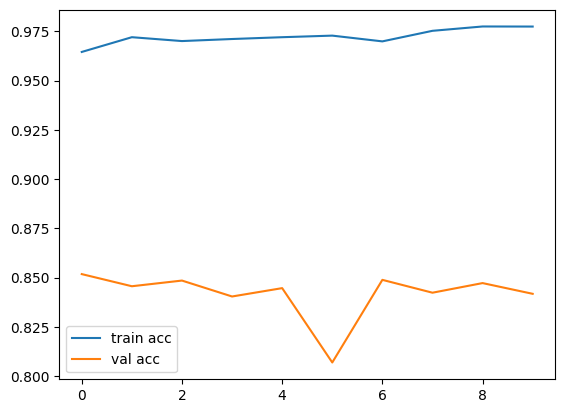

In [112]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()